# 고혈압 예측 - XGBoost Optuna SHAP 분석

- 타겟: `고혈압유병` (0: 없음 / 1: 있음)
- 모델: XGBoost (Optuna 최적 파라미터)
- 분석: OOF 전체 기준 SHAP 피처 기여도 해석
- Threshold: 0.50 고정
- 검증: Stratified 5-Fold CV

In [ ]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"


# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
NPY_DIR = "/Users/Jiyeon/Desktop/final_project/ML/outputs/oof"
RANDOM_STATE = 42
THRESHOLD = 0.50

## 1. 데이터 로드

In [16]:
df = pd.read_csv(INPUT_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (6033, 32)


## 2. 피처 / 타겟 분리

In [17]:
TARGET = "고혈압유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos
print(f"샘플 수: {len(y)}  |  정상: {neg}  |  고혈압: {pos}")

샘플 수: 6033  |  정상: 4353  |  고혈압: 1680


## 3. Optuna 최적 파라미터 설정

In [18]:
best_params = {
    "n_estimators": 685,
    "learning_rate": 0.0778277073604009,
    "max_depth": 4,
    "min_child_weight": 7,
    "subsample": 0.7894718188423783,
    "colsample_bytree": 0.9019156893528962,
    "gamma": 0.7383205249686194,
    "reg_alpha": 0.4099668976204711,
    "reg_lambda": 2.5437289023664147,
    "scale_pos_weight": ratio,
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
}
print("파라미터 설정 완료")

파라미터 설정 완료


## 4. Stratified 5-Fold CV — OOF proba & SHAP 수집

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
shap_values = np.zeros(X.shape)
fold_scores = []

print("=" * 55)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba

    # SHAP TreeExplainer
    explainer = shap.TreeExplainer(model)
    shap_values[val_idx] = explainer.shap_values(X_val)

    pred = (proba >= THRESHOLD).astype(int)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | F1: {fold_scores[-1]['f1']:.4f}"
    )

print("=" * 55)
scores_df = pd.DataFrame(fold_scores)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f} | "
    f"Recall: {scores_df.recall.mean():.4f} | F1: {scores_df.f1.mean():.4f}"
)

  Fold 1 | AUC: 0.8562 | Recall: 0.8304 | F1: 0.6481
  Fold 2 | AUC: 0.8524 | Recall: 0.8125 | F1: 0.6454
  Fold 3 | AUC: 0.8776 | Recall: 0.8363 | F1: 0.6870
  Fold 4 | AUC: 0.8296 | Recall: 0.8036 | F1: 0.6200
  Fold 5 | AUC: 0.8809 | Recall: 0.8482 | F1: 0.6762
  평균   | AUC: 0.8593 | Recall: 0.8262 | F1: 0.6553


## OOF proba 저장 (.npy)

In [20]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HP_xgboost_optuna_shap.npy")
np.save(npy_path, oof_proba)
print(f"OOF proba 저장 완료 → {npy_path}")
print(f"shape: {oof_proba.shape}, dtype: {oof_proba.dtype}")

# 저장 확인
loaded = np.load(npy_path)
print(f"로드 확인: {loaded.shape}, 일치: {np.allclose(oof_proba, loaded)}")

OOF proba 저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/outputs/oof/oof_proba_HP_xgboost_optuna_shap.npy
shape: (6033,), dtype: float64
로드 확인: (6033,), 일치: True


---
# SHAP 분석

## 5. SHAP Feature Importance (mean |SHAP|)

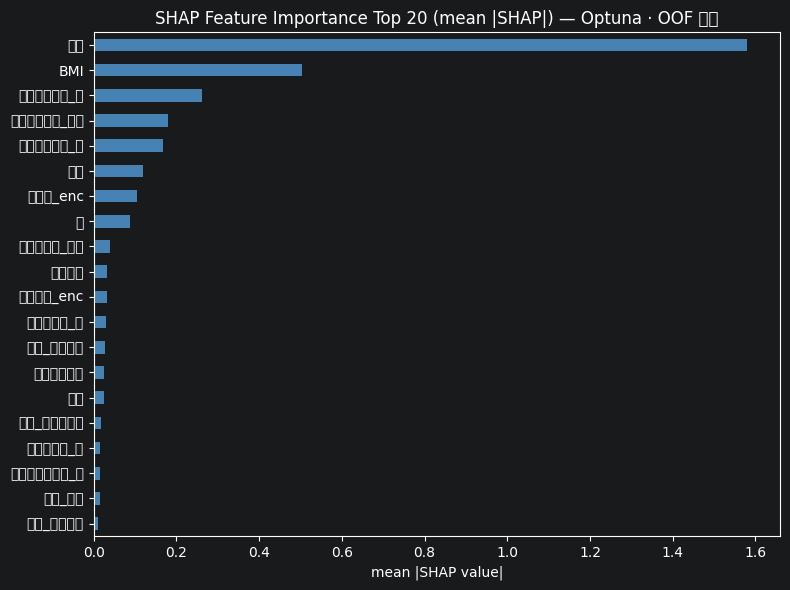

[SHAP Feature Importance Top 15]
   1. 나이: 1.5802
   2. BMI: 0.5033
   3. 고혈압가족력_모: 0.2628
   4. 고혈압가족력_형제: 0.1802
   5. 고혈압가족력_부: 0.1663
   6. 체중: 0.1189
   7. 음주량_enc: 0.1046
   8. 키: 0.0867
   9. 당뇨가족력_형제: 0.0402
  10. 걷기일수: 0.0333
  11. 음주빈도_enc: 0.0319
  12. 당뇨가족력_부: 0.0304
  13. 직업_주부학생: 0.0267
  14. 근력운동일수: 0.0253
  15. 성별: 0.0244


In [21]:
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — Optuna · OOF 전체")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

print("[SHAP Feature Importance Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 6. SHAP Summary Plot (Beeswarm)

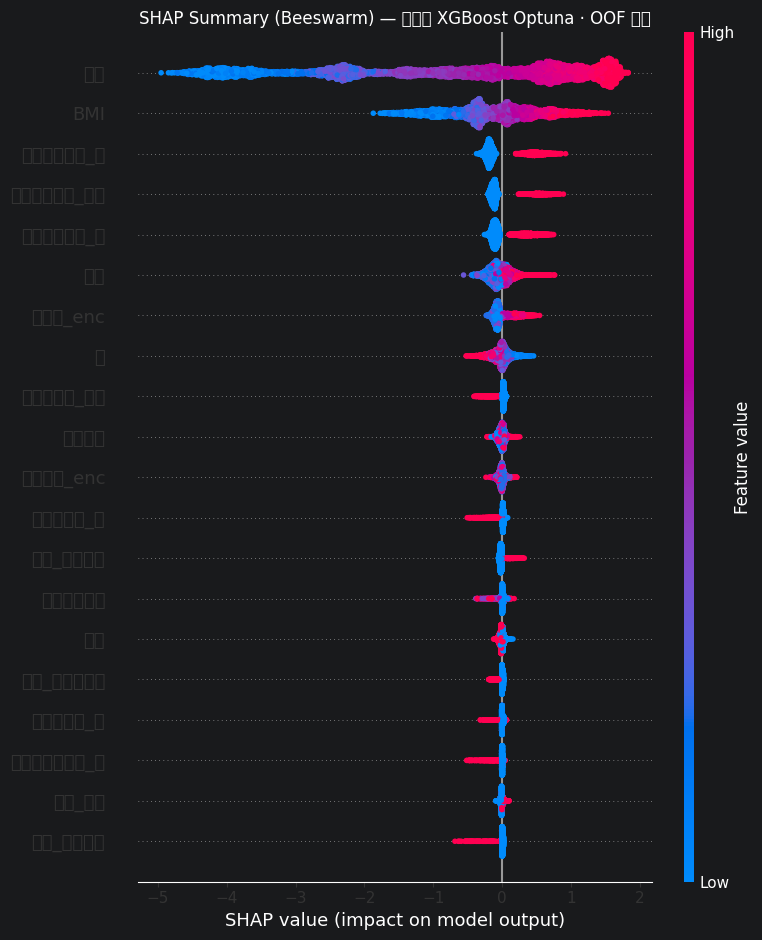

In [22]:
shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 고혈압 XGBoost Optuna · OOF 전체", fontsize=12)
plt.tight_layout()
plt.show()

## 7. SHAP Bar Plot

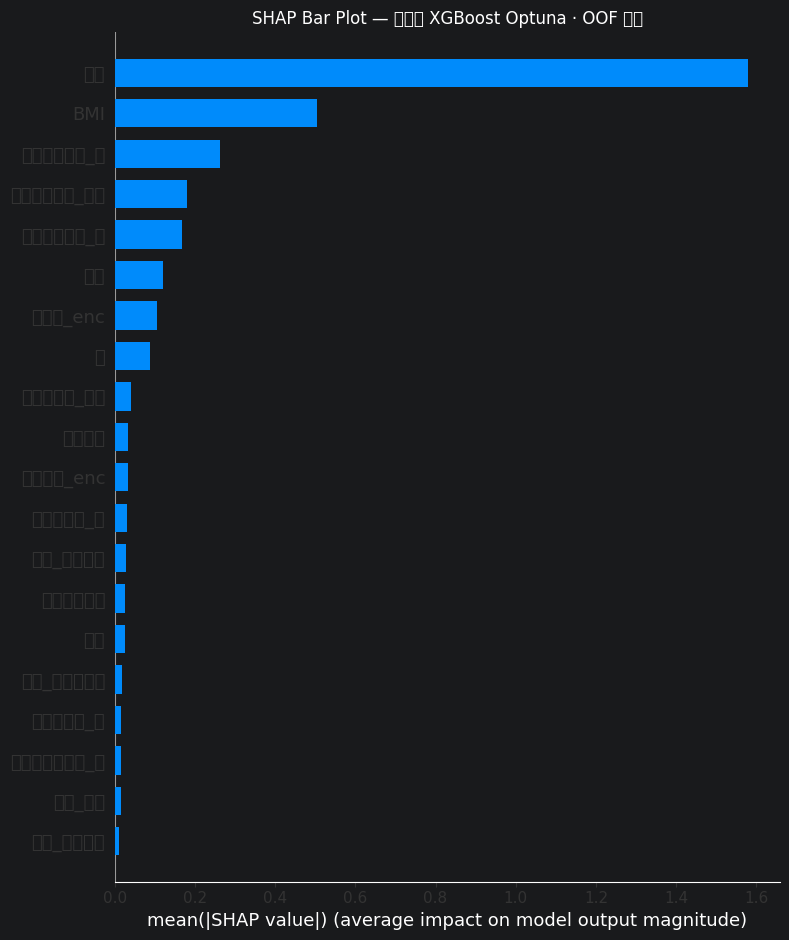

In [23]:
shap.summary_plot(shap_values, X, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Bar Plot — 고혈압 XGBoost Optuna · OOF 전체", fontsize=12)
plt.tight_layout()
plt.show()

## 8. SHAP Dependence Plot — 상위 피처 (나이, BMI)

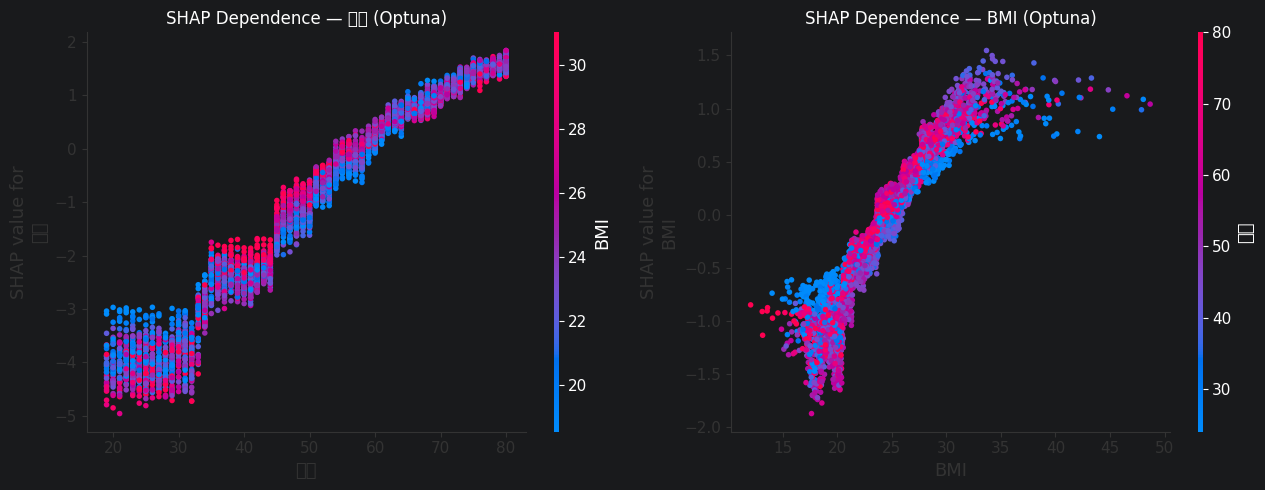

In [24]:
top2 = mean_shap.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, top2):
    shap.dependence_plot(feat, shap_values, X, ax=ax, show=False, strict=True,)
    ax.set_title(f"SHAP Dependence — {feat} (Optuna)")
plt.tight_layout()
plt.show()

## 9. SHAP Dependence Plot — 고혈압 가족력 3종

In [ ]:
fh_feats = ["고혈압가족력_모", "고혈압가족력_형제", "고혈압가족력_부"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, fh_feats, strict=True,):
    shap.dependence_plot(feat, shap_values, X, ax=ax, show=False)
    ax.set_title(f"SHAP Dependence — {feat}")
plt.suptitle("고혈압 가족력 3종 SHAP Dependence", fontsize=12)
plt.tight_layout()
plt.show()

## 10. SHAP Waterfall — 고위험 / 저위험 샘플 개별 해석

[고위험] 샘플 index=4415 | proba=0.9808 | 실제=1


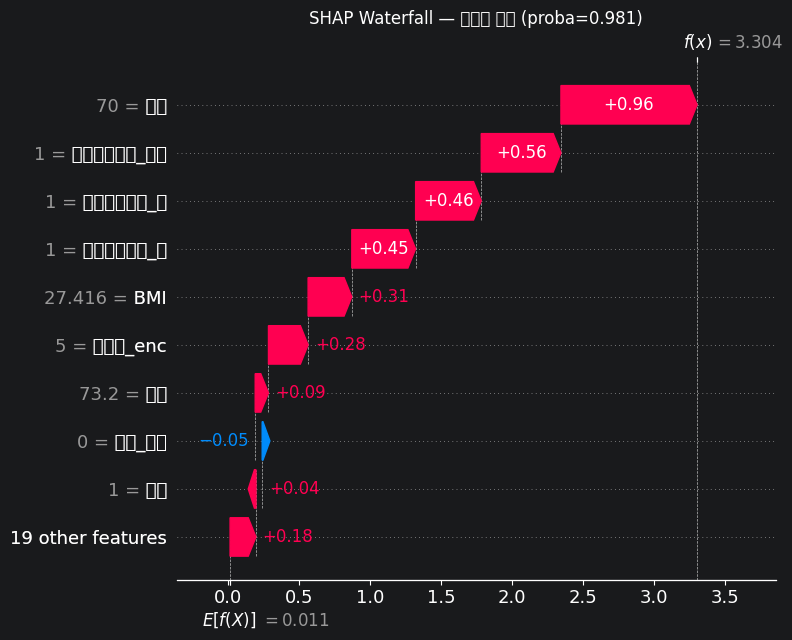

[저위험] 샘플 index=2481 | proba=0.0021 | 실제=0


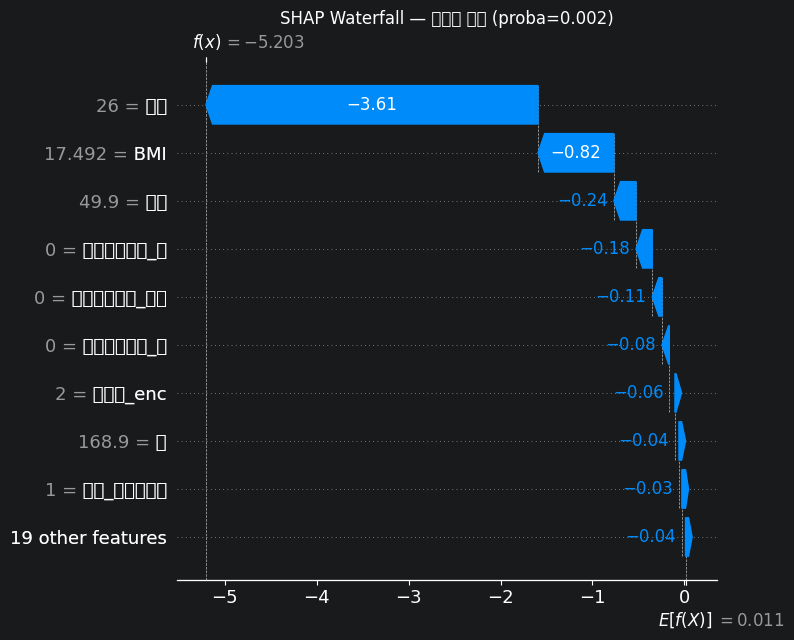

In [26]:
# 마지막 fold 모델로 explainer 재생성
explainer_last = shap.TreeExplainer(model)

# 고위험 샘플 (예측 확률 상위 1위)
high_idx = np.argsort(oof_proba)[::-1][0]
# 저위험 샘플 (예측 확률 하위 1위)
low_idx = np.argsort(oof_proba)[0]

for idx, label in [(high_idx, "고위험"), (low_idx, "저위험")]:
    shap_exp = explainer_last(X.iloc[[idx]])
    print(f"[{label}] 샘플 index={idx} | proba={oof_proba[idx]:.4f} | 실제={y.iloc[idx]}")
    shap.waterfall_plot(shap_exp[0], show=False)
    plt.title(f"SHAP Waterfall — {label} 샘플 (proba={oof_proba[idx]:.3f})")
    plt.tight_layout()
    plt.show()

## 11. Baseline vs Optuna SHAP 비교

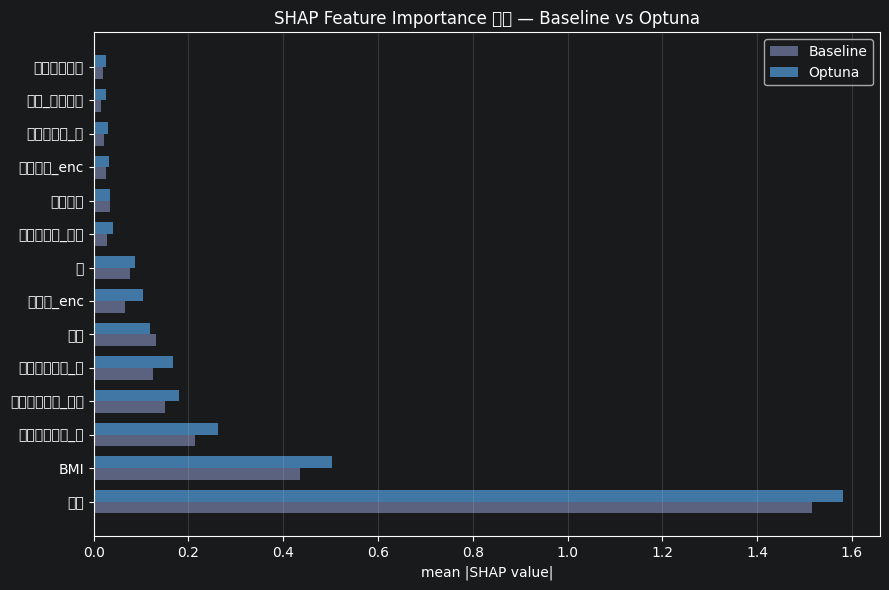

[Baseline vs Optuna SHAP 비교]
Feature                  Baseline     Optuna         변화
-------------------------------------------------------
나이                         1.5161     1.5802 ▲ 0.0641
BMI                        0.4363     0.5033 ▲ 0.0670
고혈압가족력_모                   0.2132     0.2628 ▲ 0.0496
고혈압가족력_형제                  0.1500     0.1802 ▲ 0.0302
고혈압가족력_부                   0.1251     0.1663 ▲ 0.0412
체중                         0.1313     0.1189 ▼ 0.0124
음주량_enc                    0.0650     0.1046 ▲ 0.0396
키                          0.0761     0.0867 ▲ 0.0106
당뇨가족력_형제                   0.0285     0.0402 ▲ 0.0117
걷기일수                       0.0335     0.0333 ▼ 0.0002
음주빈도_enc                   0.0252     0.0319 ▲ 0.0067
당뇨가족력_부                    0.0209     0.0304 ▲ 0.0095
직업_주부학생                    0.0159     0.0267 ▲ 0.0108
근력운동일수                     0.0204     0.0253 ▲ 0.0049


In [27]:
# Baseline SHAP Top 15 (이전 분석 결과)
baseline_shap = {
    "나이": 1.5161,
    "BMI": 0.4363,
    "고혈압가족력_모": 0.2132,
    "고혈압가족력_형제": 0.1500,
    "체중": 0.1313,
    "고혈압가족력_부": 0.1251,
    "키": 0.0761,
    "음주량_enc": 0.0650,
    "걷기일수": 0.0335,
    "당뇨가족력_형제": 0.0285,
    "음주빈도_enc": 0.0252,
    "당뇨가족력_부": 0.0209,
    "근력운동일수": 0.0204,
    "직업_주부학생": 0.0159,
    "고지혈증가족력_모": 0.0148,
}
optuna_shap = mean_shap.head(15).to_dict()

compare_df = (
    pd.DataFrame(
        {
            "Baseline": pd.Series(baseline_shap),
            "Optuna": pd.Series(optuna_shap),
        }
    )
    .dropna()
    .sort_values("Optuna", ascending=False)
)

compare_df["변화"] = compare_df["Optuna"] - compare_df["Baseline"]

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(compare_df))
w = 0.35
ax.barh(x - w / 2, compare_df["Baseline"], w, label="Baseline", color="#6b7599", alpha=0.8)
ax.barh(x + w / 2, compare_df["Optuna"], w, label="Optuna", color="steelblue", alpha=0.9)
ax.set_yticks(x)
ax.set_yticklabels(compare_df.index)
ax.set_xlabel("mean |SHAP value|")
ax.set_title("SHAP Feature Importance 비교 — Baseline vs Optuna")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("[Baseline vs Optuna SHAP 비교]")
print(f"{'Feature':<22} {'Baseline':>10} {'Optuna':>10} {'변화':>10}")
print("-" * 55)
for feat, row in compare_df.iterrows():
    arrow = "▲" if row["변화"] > 0 else "▼"
    print(f"{feat:<22} {row['Baseline']:>10.4f} {row['Optuna']:>10.4f} {arrow} {abs(row['변화']):.4f}")

## 12. DB 로그 저장

In [28]:
import sys

sys.path.insert(0, "/Users/Jiyeon/Desktop/final_project/ML")
from model_logger import ModelLogger

logger = ModelLogger("/Users/Jiyeon/Desktop/final_project/ML/model_result.db")

pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

run_id = logger.log_run(
    target_var="고혈압",
    model_name="XGBoost",
    stage="optuna_shap",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "n_estimators": best_params["n_estimators"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "min_child_weight": best_params["min_child_weight"],
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],
        "gamma": best_params["gamma"],
        "reg_alpha": best_params["reg_alpha"],
        "reg_lambda": best_params["reg_lambda"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": float((pred_oof == y).mean()),
        "recall": recall_score(y, pred_oof),
        "precision": precision_score(y, pred_oof),
        "f1_score": f1_score(y, pred_oof),
        "auc_roc": roc_auc_score(y, oof_proba),
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=mean_shap.head(15).to_dict(),
    note="Optuna 최적 파라미터 기준 SHAP 분석. top_features = SHAP mean|shap| 기준.",
)

print(f"저장 완료 → run_id: {run_id}")
print()
print("[전체 실험 목록]")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=4 | 고혈압 XGBoost (optuna_shap)
저장 완료 → run_id: 4

[전체 실험 목록]
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
      4 2026-05-15 16:25:48        고혈압    XGBoost    optuna_shap 0.859112 0.826190   0.542399  0.654871  0.757500
      3 2026-05-15 16:22:42        고혈압    XGBoost    optuna_shap 0.859112 0.826190   0.542399  0.654871  0.757500
      2 2026-05-15 15:55:46        고혈압    XGBoost         optuna 0.859112 0.826190   0.542399  0.654871  0.757500
      1 2026-05-15 15:30:15        고혈압    XGBoost threshold_0.55 0.853083 0.771429   0.561769  0.650113  0.768772
